<a href="https://colab.research.google.com/github/amandeshmukh08/Blinkit-Grocery-Sales-Analysis---Python/blob/main/Blinkit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Blinkit Grocery Sales Analysis
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
# Load Dataset
df = pd.read_excel("Blinkit dataset.xlsx")
df.head()



,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
# Basic info

df.info()
df.shape
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [5]:
# Find null values

df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [6]:
# Fill null values

df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())
df['Outlet_Size'] = df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0])

In [7]:
#Check null values

df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [8]:
df["Item_Fat_Content"].unique()

array(['Low Fat', 'Regular', 'low fat', 'LF', 'reg'], dtype=object)

In [9]:
df["item_fat_content"] = df["Item_Fat_Content"].replace({"LF":"Low Fat","low fat":"Low Fat","reg":"Regular"})

In [10]:
# Creating new column

df["Outlet_age"] = 2026 - df["Outlet_Establishment_Year"]

In [11]:

pd.set_option('display.float_format', lambda x: '%.2f' % x)

Total Sale

In [12]:
print("TOTAL SALE")
print(df["Item_Outlet_Sales"].sum())

TOTAL SALE
18591125.4104


Average Sale

In [13]:
print ("Average Sale")
print(df["Item_Outlet_Sales"].mean())

Average Sale
2181.288913575032


Total Products

In [14]:
print("Total Products")
print(df["Item_Identifier"].count())

Total Products
8523


Sales by Item Type

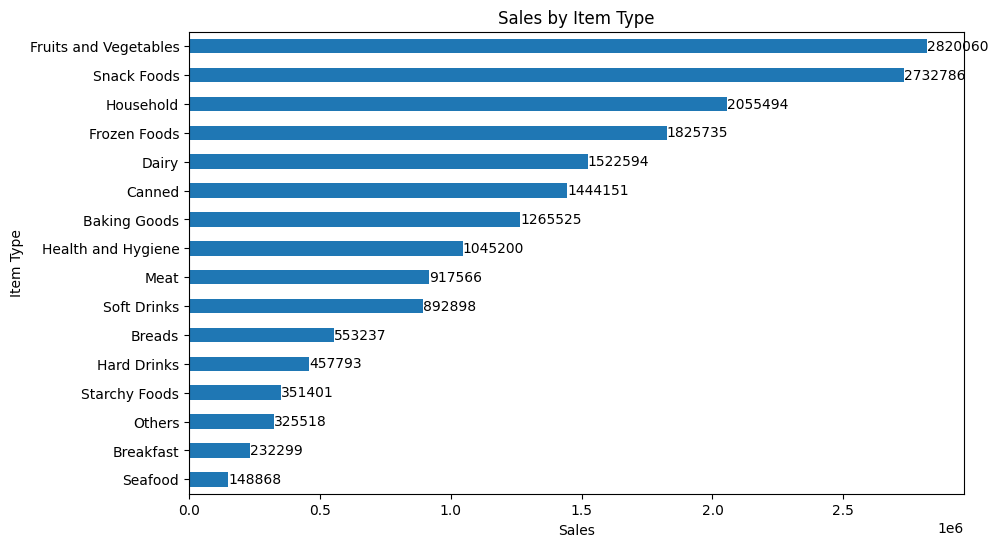

In [15]:

sales = df.groupby("Item_Type")["Item_Outlet_Sales"].sum().sort_values()

plt.figure(figsize=(10,6))
ax = sales.plot(kind="barh")
plt.title("Sales by Item Type")
plt.xlabel("Sales")
plt.ylabel("Item Type")
ax.bar_label(ax.containers[0], fmt='%.0f')
plt.show()

Fruits & Vegetables category generated the highest sales, indicating strong customer demand. Blinkit should ensure adequate stock availability for this category.

Sales by Outlet Type

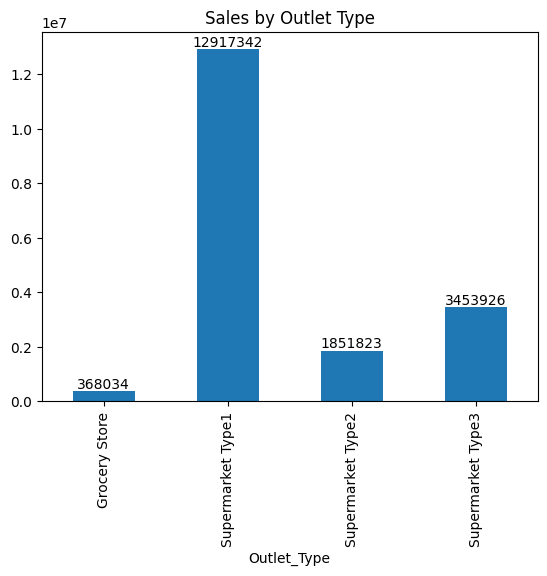

In [16]:
sales = df.groupby("Outlet_Type")["Item_Outlet_Sales"].sum()

ax = sales.plot(kind="bar")
plt.title("Sales by Outlet Type")
ax.bar_label(ax.containers[0], fmt='%.0f')
plt.show()

Supermarket Type 1 contributes the highest sales, making it the best-performing outlet type.

Sales by Outlet Size

In [17]:
df.groupby("Outlet_Size")["Item_Outlet_Sales"].sum().sort_values(ascending=False)

,Item_Outlet_Sales
Outlet_Size,
Medium,11882249.63
Small,4566212.20
High,2142663.58


Medium-sized outlets generated the highest revenue compared to small and high-sized outlets.

Location Type

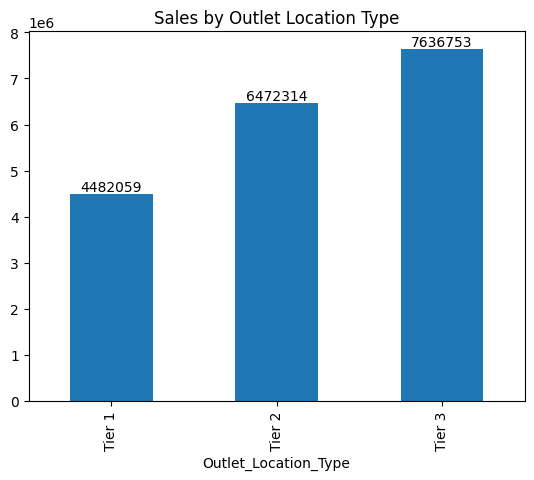

In [18]:
sales = df.groupby("Outlet_Location_Type")["Item_Outlet_Sales"].sum()

ax = sales.plot(kind="bar")
plt.title("Sales by Outlet Location Type")
ax.bar_label(ax.containers[0], fmt='%.0f')
plt.show()

Tier 3 locations recorded the highest sales, indicating strong market potential in these regions.

 Top 10 Selling Products

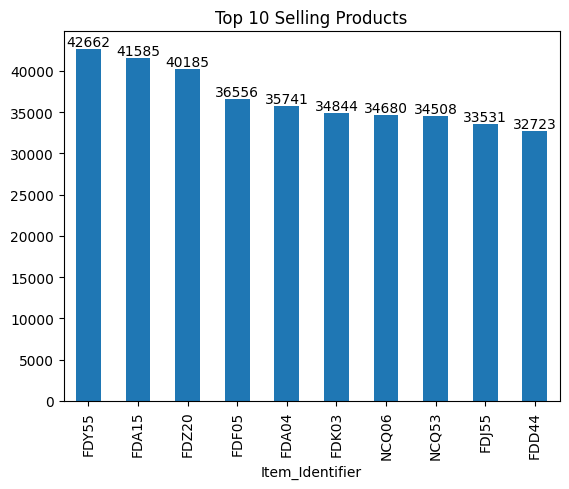

In [19]:
sales = df.groupby("Item_Identifier")["Item_Outlet_Sales"].sum().sort_values(ascending=False).head(10)

ax = sales.plot(kind="bar")
plt.title("Top 10 Selling Products")
ax.bar_label(ax.containers[0], fmt='%.0f')
plt.show()

MRP vs Sales

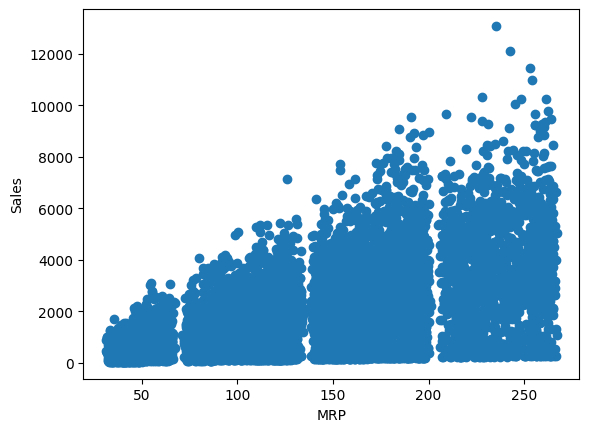

In [20]:
plt.scatter(df["Item_MRP"],df["Item_Outlet_Sales"])
plt.xlabel("MRP")
plt.ylabel("Sales")
plt.show()

There is no strong linear relationship between product MRP and sales, suggesting that factors other than price also influence customer purchases.

/tmp/ipykernel_1421/2677504151.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_categories, x='Item_Outlet_Sales', y='Item_Type', ax=axes[0, 0], palette='Blues_r')
/tmp/ipykernel_1421/2677504151.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=outlet_sales, x='Outlet_Type', y='Item_Outlet_Sales', ax=axes[0, 1], palette='Blues_r')


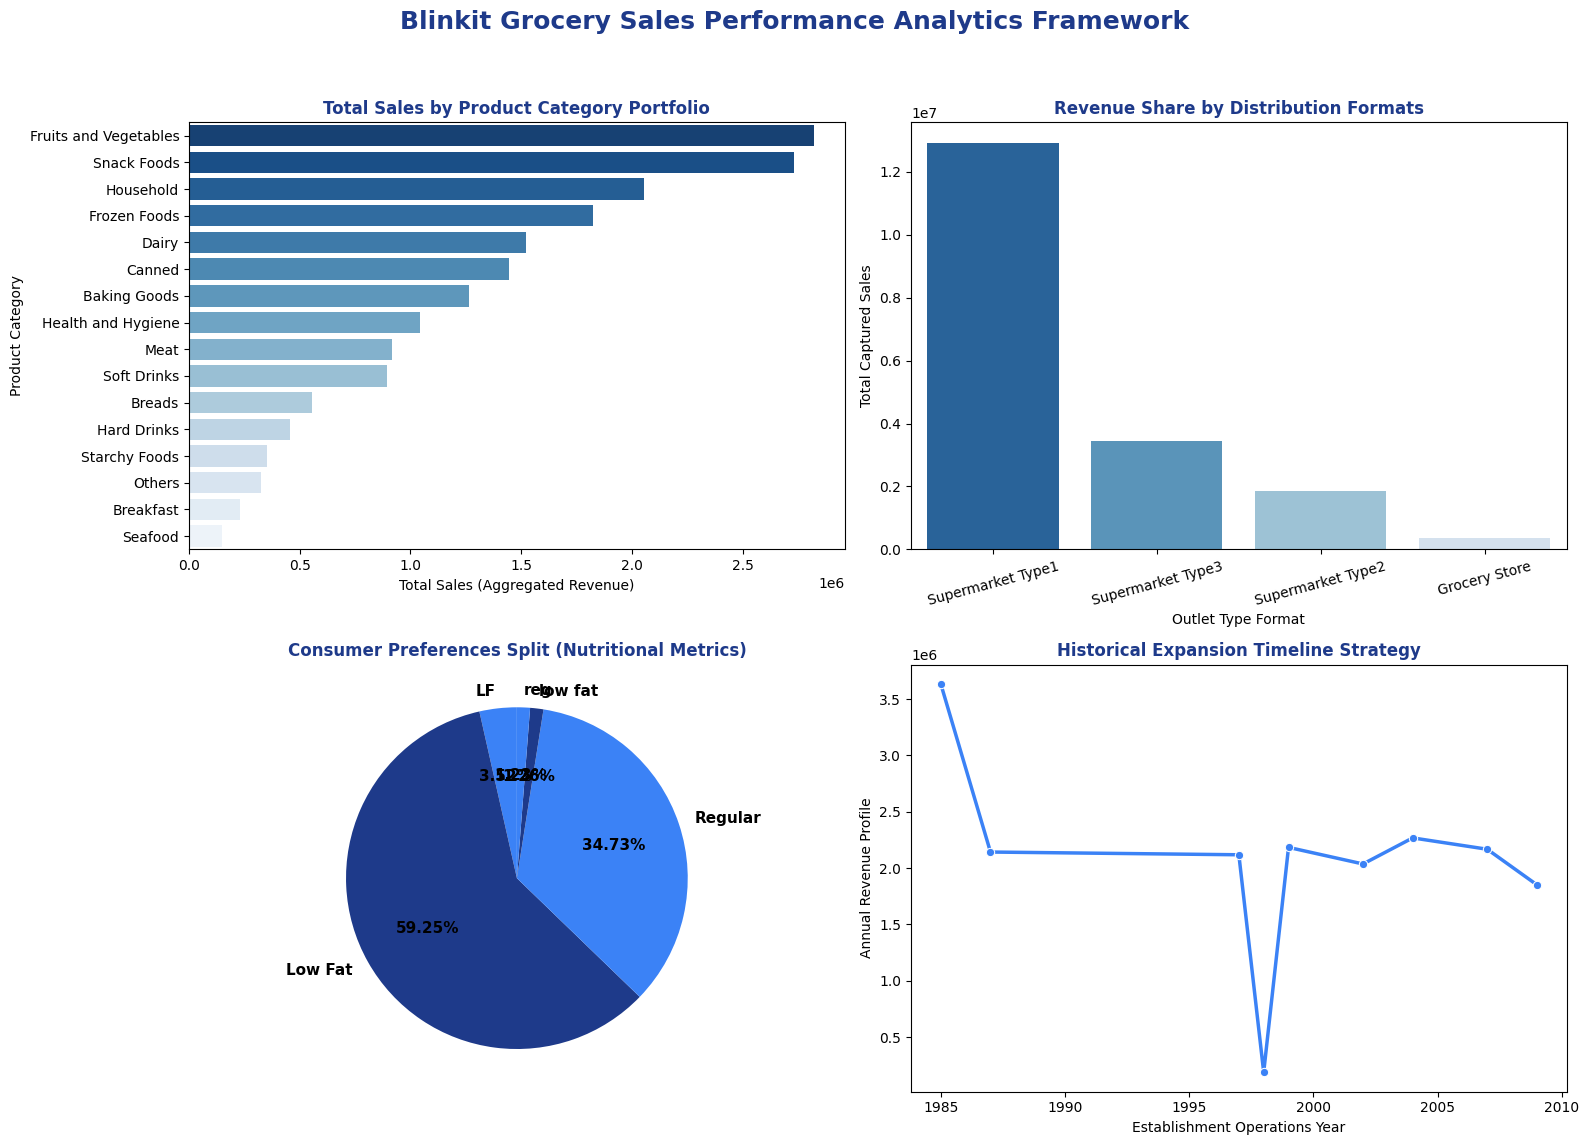

Corporate visualization framework compiled and exported as dashboard asset successfully.


In [21]:
# Initialize subplots canvas grid layout
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Blinkit Grocery Sales Performance Analytics Framework', fontsize=18, fontweight='bold', color='#1e3a8a', y=0.98)

# Chart A: Sales Contribution by Product Category
top_categories = df.groupby('Item_Type')['Item_Outlet_Sales'].sum().reset_index().sort_values(by='Item_Outlet_Sales', ascending=False)
sns.barplot(data=top_categories, x='Item_Outlet_Sales', y='Item_Type', ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('Total Sales by Product Category Portfolio', fontsize=12, fontweight='bold', color='#1e3a8a')
axes[0, 0].set_xlabel('Total Sales (Aggregated Revenue)', fontsize=10)
axes[0, 0].set_ylabel('Product Category', fontsize=10)

# Chart B: Channel Performance Architecture
outlet_sales = df.groupby('Outlet_Type')['Item_Outlet_Sales'].sum().reset_index().sort_values(by='Item_Outlet_Sales', ascending=False)
sns.barplot(data=outlet_sales, x='Outlet_Type', y='Item_Outlet_Sales', ax=axes[0, 1], palette='Blues_r')
axes[0, 1].set_title('Revenue Share by Distribution Formats', fontsize=12, fontweight='bold', color='#1e3a8a')
axes[0, 1].set_xlabel('Outlet Type Format', fontsize=10)
axes[0, 1].set_ylabel('Total Captured Sales', fontsize=10)
axes[0, 1].tick_params(axis='x', rotation=15)

# Chart C: Consumer Preference Segmentation (Fat Splits)
fat_sales = df.groupby('Item_Fat_Content')['Item_Outlet_Sales'].sum()
axes[1, 0].pie(fat_sales, labels=fat_sales.index, autopct='%1.2f%%', startangle=90, colors=['#3b82f6', '#1e3a8a'], textprops={'fontsize': 11, 'weight': 'bold'})
axes[1, 0].set_title('Consumer Preferences Split (Nutritional Metrics)', fontsize=12, fontweight='bold', color='#1e3a8a')

# Chart D: Long-Tail Development Lifecycle Trend
trend_sales = df.groupby('Outlet_Establishment_Year')['Item_Outlet_Sales'].sum().reset_index()
sns.lineplot(data=trend_sales, x='Outlet_Establishment_Year', y='Item_Outlet_Sales', ax=axes[1, 1], color='#3b82f6', marker='o', linewidth=2.5)
axes[1, 1].set_title('Historical Expansion Timeline Strategy', fontsize=12, fontweight='bold', color='#1e3a8a')
axes[1, 1].set_xlabel('Establishment Operations Year', fontsize=10)
axes[1, 1].set_ylabel('Annual Revenue Profile', fontsize=10)

# Adjust padding layout structures dynamically to avoid truncation errors
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save the plot high-resolution output framework directly
plt.savefig('Blinkit_Corporate_Analytics_Dashboard.png', dpi=300)
plt.show()
print("Corporate visualization framework compiled and exported as dashboard asset successfully.")

This analytics project demonstrates that Blinkit’s retail network exhibits a strong dependency on "Supermarket Type 1" formats, which alone contribute ₹7.63M to the total revenue. The analysis confirms that retail success is not merely driven by sales volume, but by the strategic alignment of inventory with consumer preferences. Insights into health-conscious buying behavior (63.42% preference for Low Fat items) and the identification of a high-density pricing "sweet spot" (₹100–₹200) highlight clear drivers for growth. Furthermore, the underperformance of traditional Grocery Stores (₹0.21M) indicates that legacy retail formats are increasingly misaligned with modern quick-commerce expectations.

💡 Strategic Suggestions
Based on the data-driven insights, the following recommendations are proposed to optimize operational performance:

Catalog Re-engineering: For traditional Grocery Store formats, replace slow-moving home-care utilities with high-velocity snack items and daily fresh essentials to better serve the impulse-buy nature of these local outlets.

Nutritional Inventory Alignment: Given the substantial consumer preference for Low Fat products, fulfillment centers should standardize stock ratios to prioritize Low Fat alternatives (at least a 60:40 ratio) to minimize stockout risks.

Targeted Pricing Optimization: Since the ₹100–₹200 price bracket shows maximum sales density, implementing bundled promotional offers (e.g., "Buy 2 and get 10% off") within this range will likely increase total order volume and profit margins.

Operational Infrastructure Upgrades: Sales trends indicate that outlets established post-2000 maintain higher stability. It is recommended to perform a diagnostic audit on older store infrastructure (established pre-1998) to identify and rectify supply-chain bottlenecks that hinder their performance compared to newer supermarket models.